# Assignment 3: LCS Employer Segmentation Using K-Means

**Client:** Lindner Career Services  
**Role:** Data Science Consulting Team  
**Team Members:** Sukanya Chatterjee, Mehak Tiku,Narayan Shanku, Charles James

This notebook segments LCS co-op employers into business tiers using K-Means clustering. The goal is to help LCS prioritize employer relationship management based on hiring volume, wage levels, employer consistency, and student opportunity coverage.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 1. Loading and Reviewing Dataset

The cleaned master co-op dataset was loaded into Python. Initial checks were performed to review column names, missing values, and overall structure before preparing the data for clustering.

In [4]:
df = pd.read_excel("cleaned_master_dataset (1).xlsx")

df.head()

,Id,Primary_Major,Student College,Student Education Level,Student School Year,Student Work Authorization,Employer_Clean,Employer Industry,Job_Clean,Job_Type_Clean,...,Is_Remote,Hourly_Wage_Clean,Is_Paid_Disclosed,Hourly_Wage_Imputed,Job_Description,Job_Source,Hours_Per_Week_Survey,Salary_Survey_Raw,Data_Instrument_Era,DQ_OfferAfterStart
0,67212,Marketing,Carl H. Lindner College of Business,Bachelors,Alumni,NaN,SugarCreek,Manufacturing,Marketing Intern,Internship,...,0,15.0,1,15.0,NaN,NaN,NaN,NaN,survey-v1,0
1,67480,Finance,Carl H. Lindner College of Business,Bachelors,Alumni,NaN,Amstan Logistics,NaN,Household Goods Intern,Internship,...,0,12.0,1,12.0,NaN,NaN,NaN,NaN,survey-v1,0
2,67696,Accounting,Carl H. Lindner College of Business,Bachelors,Alumni,NaN,TSC Apparel,Wholesale Trade,Accounting Intern,Cooperative Education,...,0,10.0,1,10.0,NaN,NaN,NaN,NaN,survey-v1,0
3,68474,Aviation Technology,Clermont College,Associates,Sophomore,NaN,BMW Manufacturing Co,Automotive,Purchasing,Cooperative Education,...,0,16.5,1,16.5,NaN,NaN,NaN,NaN,survey-v1,0
4,69342,Operations Management,Carl H. Lindner College of Business,Bachelors,Alumni,NaN,GE Appliances,Manufacturing,Supply Chain Management,Cooperative Education,...,0,22.5,1,22.5,NaN,NaN,NaN,NaN,survey-v1,0


In [5]:
df.columns

Index(['Id', 'Primary_Major', 'Student College', 'Student Education Level',
       'Student School Year', 'Student Work Authorization', 'Employer_Clean',
       'Employer Industry', 'Job_Clean', 'Job_Type_Clean', 'Status_Clean',
       'Term_Label', 'Term_End_Date', 'Start_Date_Clean', 'End_Date_Clean',
       'Offer_Date_Clean', 'Offer_Accepted_Date_Clean',
       'Graduation_Date_Clean', 'Location', 'City', 'State', 'Is_Remote',
       'Hourly_Wage_Clean', 'Is_Paid_Disclosed', 'Hourly_Wage_Imputed',
       'Job_Description', 'Job_Source', 'Hours_Per_Week_Survey',
       'Salary_Survey_Raw', 'Data_Instrument_Era', 'DQ_OfferAfterStart'],
      dtype='str')

In [6]:
df.isna().sum().sort_values(ascending=False)

Student Work Authorization    9891
Term_End_Date                 6200
Offer_Accepted_Date_Clean     4374
Hourly_Wage_Clean             3969
Job_Type_Clean                3820
End_Date_Clean                3706
Start_Date_Clean              3251
Offer_Date_Clean              3041
Employer Industry             2384
State                         1094
City                           932
Location                       884
Salary_Survey_Raw              824
Job_Source                     309
Job_Description                226
Hours_Per_Week_Survey          215
Term_Label                      22
Graduation_Date_Clean           19
Job_Clean                       14
Primary_Major                    5
Employer_Clean                   0
Student College                  0
Id                               0
Status_Clean                     0
Student Education Level          0
Student School Year              0
Is_Remote                        0
Is_Paid_Disclosed                0
Hourly_Wage_Imputed 

## 2. Data Cleaning and Missing Value Treatment

The raw dataset contained some incomplete descriptive fields such as job descriptions, job source, and raw salary survey responses. These columns were not used for clustering. Instead, the analysis used the cleaned fields to improve consistency.

In [7]:
df["Status_Clean"].value_counts()

Status_Clean
Approved          6076
Completed         3202
Declined           442
needs_review       288
Pending            124
being_approved      10
Name: count, dtype: int64

## 3. Selecting Relevant Columns

Only the columns needed for employer segmentation were retained. The clustering analysis focuses on employer name, status, term, major, industry, hourly wage, and remote indicator.

In [8]:
required_cols = [
    "Employer_Clean",
    "Status_Clean",
    "Term_Label",
    "Primary_Major",
    "Employer Industry",
    "Hourly_Wage_Imputed",
    "Is_Remote"
]

df_required = df[required_cols].copy()

df_required.head()

,Employer_Clean,Status_Clean,Term_Label,Primary_Major,Employer Industry,Hourly_Wage_Imputed,Is_Remote
0,SugarCreek,Declined,Spring 2021,Marketing,Manufacturing,15.0,0
1,Amstan Logistics,Completed,Summer 2021,Finance,NaN,12.0,0
2,TSC Apparel,Completed,Summer 2021,Accounting,Wholesale Trade,10.0,0
3,BMW Manufacturing Co,Completed,Fall 2020,Aviation Technology,Automotive,16.5,0
4,GE Appliances,Completed,Fall 2020,Operations Management,Manufacturing,22.5,0


In [9]:
df_required.shape

(10142, 7)

In [10]:
df_coop = df_required[
    df_required["Status_Clean"].isin(["Approved", "Completed"])
].copy()

df_coop.shape

(9278, 7)

## 4. Cleaning Missing and Inconsistent Values

Missing categorical values were labeled as `NA`, and text fields were standardized by removing extra spaces. Numerical fields used in clustering were converted to numeric format so they could be used safely in the model.

In [12]:
text_cols = [
    "Employer_Clean",
    "Status_Clean",
    "Term_Label",
    "Primary_Major",
    "Employer Industry"
]

for col in text_cols:
    df_coop[col] = (
        df_coop[col]
        .fillna("NA")
        .astype(str)
        .str.strip()
        .replace(["nan", "NaN", "None", "none", ""], "NA")
    )

df_coop[text_cols].isna().sum()

Employer_Clean       0
Status_Clean         0
Term_Label           0
Primary_Major        0
Employer Industry    0
dtype: int64

In [13]:
for col in text_cols:
    print(col)
    print(df_coop[col].value_counts().head(10))
    print()

Employer_Clean
Employer_Clean
Great American Insurance Group       328
Phillips Edison & Company            173
Kroger                               141
Fifth Third Bank                     124
AMEND Consulting                     118
University of Cincinnati              96
GE Aviation                           84
Reliable Transportation Solutions     84
Paycor                                82
Medpace, Inc                          77
Name: count, dtype: int64

Status_Clean
Status_Clean
Approved     6076
Completed    3202
Name: count, dtype: int64

Term_Label
Term_Label
Summer 2021    1529
Spring 2021    1280
Fall 2020       919
Summer 2025     642
Summer 2022     601
Summer 2023     581
Summer 2024     524
Spring 2022     444
Spring 2026     352
Fall 2021       340
Name: count, dtype: int64

Primary_Major
Primary_Major
Marketing                        2265
Finance                          1870
Accounting                       1163
Operations Management             815
Business Analyt

In [14]:
df_coop["Hourly_Wage_Imputed"] = pd.to_numeric(
    df_coop["Hourly_Wage_Imputed"], errors="coerce"
)

df_coop["Is_Remote"] = pd.to_numeric(
    df_coop["Is_Remote"], errors="coerce"
)

df_coop["Hourly_Wage_Imputed"] = df_coop["Hourly_Wage_Imputed"].fillna(
    df_coop["Hourly_Wage_Imputed"].median()
)

df_coop["Is_Remote"] = df_coop["Is_Remote"].fillna(0)

df_coop.isna().sum()

Employer_Clean         0
Status_Clean           0
Term_Label             0
Primary_Major          0
Employer Industry      0
Hourly_Wage_Imputed    0
Is_Remote              0
dtype: int64

## 5. Create Year and Season Features

The `Term_Label` column was split into separate `Year` and `Season` fields. These features help measure how consistently each employer appears across different years and recruiting terms.

In [15]:
df_coop["Year"] = df_coop["Term_Label"].str.extract(r"(20\d{2})")
df_coop["Year"] = pd.to_numeric(df_coop["Year"], errors="coerce")

df_coop["Season"] = df_coop["Term_Label"].str.extract(r"(Spring|Summer|Fall)")
df_coop["Season"] = df_coop["Season"].fillna("NA")

df_coop[["Term_Label", "Year", "Season"]].head(10)

,Term_Label,Year,Season
1,Summer 2021,2021.0,Summer
2,Summer 2021,2021.0,Summer
3,Fall 2020,2020.0,Fall
4,Fall 2020,2020.0,Fall
5,Fall 2020,2020.0,Fall
6,Summer 2021,2021.0,Summer
7,Fall 2020,2020.0,Fall
8,Summer 2021,2021.0,Summer
9,Fall 2020,2020.0,Fall
10,Fall 2020,2020.0,Fall


In [16]:
df_coop[["Year", "Season"]].isna().sum()

Year      20
Season     0
dtype: int64

In [17]:
df_coop[df_coop["Year"].isna()][["Employer_Clean", "Term_Label", "Year", "Season"]]

,Employer_Clean,Term_Label,Year,Season
590,TJX Companies,NA,NaN,NA
614,ARCO/Murray Design Build,NA,NaN,NA
835,Rhinestahl Corporation,NA,NaN,NA
1674,Ernst & Young LLP - EY,NA,NaN,NA
2639,Target,NA,NaN,NA
2723,L.M. Kohn,NA,NaN,NA
2724,GE Aviation,NA,NaN,NA
2725,Great American Insurance Group,NA,NaN,NA
2726,Ernst & Young LLP (EY),NA,NaN,NA
2727,Charity Mobile,NA,NaN,NA


In [18]:
df_coop["Year"] = df_coop["Year"].fillna(0)

df_coop[["Year", "Season"]].isna().sum()

Year      0
Season    0
dtype: int64

## 6. Cleaning Employer Names

The employer name field was cleaned by removing extra quotation marks and spaces. Clearly blank or unknown employer values were excluded. Other employer names were retained to avoid removing valid companies with unusual legal names.

In [54]:
df_coop["Employer_Final"] = df_coop["Employer_Clean"].copy()

df_coop["Employer_Final"] = (
    df_coop["Employer_Final"]
    .astype(str)
    .str.replace('"', '', regex=False)
    .str.strip()
)

df_coop_clean = df_coop.copy()

df_coop_clean.head()

,Employer_Clean,Status_Clean,Term_Label,Primary_Major,Employer Industry,Hourly_Wage_Imputed,Is_Remote,Year,Season,Employer_Final,Looks_Like_Address
1,Amstan Logistics,Completed,Summer 2021,Finance,NA,12.0,0,2021.0,Summer,Amstan Logistics,False
2,TSC Apparel,Completed,Summer 2021,Accounting,Wholesale Trade,10.0,0,2021.0,Summer,TSC Apparel,False
3,BMW Manufacturing Co,Completed,Fall 2020,Aviation Technology,Automotive,16.5,0,2020.0,Fall,BMW Manufacturing Co,False
4,GE Appliances,Completed,Fall 2020,Operations Management,Manufacturing,22.5,0,2020.0,Fall,GE Appliances,False
5,GE Appliances,Completed,Fall 2020,Operations Management,Manufacturing,22.5,0,2020.0,Fall,GE Appliances,False


In [55]:
bad_employers = ["NA", "N/A", "None", "none", "nan", "Unknown", "TBD", ""]

df_coop_clean = df_coop_clean[
    ~df_coop_clean["Employer_Final"].isin(bad_employers)
].copy()

df_coop_clean.shape

(9278, 11)

## 7. Creating Employer-Level Dataset

The original dataset contains one row per co-op record. For employer segmentation, the data was aggregated so each row represents one employer.

The employer-level features include total hires, average hourly wage, number of majors served, number of industries served, years active, seasons active, and remote hiring rate.

In [34]:
employer_df = df_coop_clean.groupby("Employer_Final").agg(
    Total_Hires=("Employer_Final", "count"),
    Avg_Hourly_Wage=("Hourly_Wage_Imputed", "mean"),
    Majors_Served=("Primary_Major", "nunique"),
    Industries_Served=("Employer Industry", "nunique"),
    Years_Active=("Year", lambda x: x[x != 0].nunique()),
    Seasons_Active=("Season", "nunique"),
    Remote_Rate=("Is_Remote", "mean")
).reset_index()

employer_df = employer_df.rename(columns={"Employer_Final": "Employer"})

employer_df.sort_values("Total_Hires", ascending=False).head(30)

,Employer,Total_Hires,Avg_Hourly_Wage,Majors_Served,Industries_Served,Years_Active,Seasons_Active,Remote_Rate
1056,Great American Insurance Group,328,18.153415,21,2,7,4,0.0
1926,Phillips Edison & Company,173,17.485549,19,2,7,3,0.0
1379,Kroger,141,17.765035,19,2,7,3,0.0
899,Fifth Third Bank,124,22.543226,15,2,7,3,0.0
44,AMEND Consulting,118,18.977966,14,3,7,3,0.0
2573,University of Cincinnati,96,15.183542,21,3,7,3,0.0
984,GE Aviation,84,21.697024,16,2,5,4,0.0
2058,Reliable Transportation Solutions,84,14.912738,13,2,6,3,0.0
1892,Paycor,82,18.138415,15,1,6,3,0.0
1620,"Medpace, Inc",77,18.116883,13,2,7,3,0.0


In [35]:
employer_df.isna().sum()

Employer             0
Total_Hires          0
Avg_Hourly_Wage      0
Majors_Served        0
Industries_Served    0
Years_Active         0
Seasons_Active       0
Remote_Rate          0
dtype: int64

In [36]:
numeric_cols = [
    "Total_Hires",
    "Avg_Hourly_Wage",
    "Majors_Served",
    "Industries_Served",
    "Years_Active",
    "Seasons_Active",
    "Remote_Rate"
]

employer_df[numeric_cols] = employer_df[numeric_cols].apply(pd.to_numeric, errors="coerce")
employer_df[numeric_cols] = employer_df[numeric_cols].fillna(0)

employer_df.isna().sum()

Employer             0
Total_Hires          0
Avg_Hourly_Wage      0
Majors_Served        0
Industries_Served    0
Years_Active         0
Seasons_Active       0
Remote_Rate          0
dtype: int64

In [37]:
employer_df.to_csv("lcs_employers.csv", index=False)

print("lcs_employers.csv saved successfully")

lcs_employers.csv saved successfully


## 8. Standardizing Numerical Features

K-Means is a distance-based algorithm, so the numerical variables were standardized before clustering. This prevents features with larger scales, such as total hires, from dominating the model.

In [39]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

X = employer_df[numeric_cols]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

## 9. Elbow Method

K-Means models were tested for K = 1 through K = 10. The inertia values were plotted to identify a reasonable number of employer tiers.

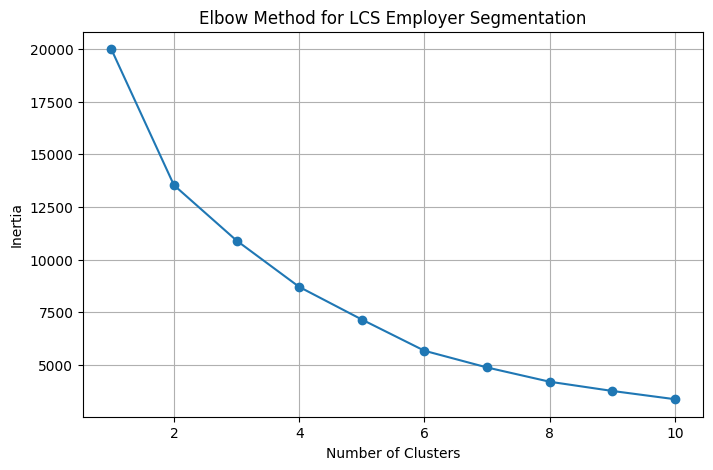

In [40]:
inertias = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(1, 11), inertias, marker="o")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method for LCS Employer Segmentation")
plt.grid(True)
plt.show()

## 10. Selecting Final Number of Clusters 

Based on the elbow plot, K = 4 was selected because the decrease in inertia begins to slow after four clusters. This provides a practical number of employer tiers for LCS to use in relationship management.

In [42]:
optimal_k = 4

final_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
employer_df["Cluster_Tier"] = final_model.fit_predict(X_scaled)

employer_df.head()

,Employer,Total_Hires,Avg_Hourly_Wage,Majors_Served,Industries_Served,Years_Active,Seasons_Active,Remote_Rate,Cluster_Tier
0,1-800 WATER DAMAGE,1,17.0,1,1,1,1,0.0,1
1,1628 Ltd,10,14.5,3,2,3,3,0.0,2
2,1819 Innovation Hub,2,12.0,2,1,1,2,0.0,1
3,1N5,1,7.5,1,1,1,1,0.0,1
4,1st Day School Supplies,1,18.0,1,1,1,1,0.0,1


In [43]:
employer_df.sort_values("Total_Hires", ascending=False).head(30)

,Employer,Total_Hires,Avg_Hourly_Wage,Majors_Served,Industries_Served,Years_Active,Seasons_Active,Remote_Rate,Cluster_Tier
1056,Great American Insurance Group,328,18.153415,21,2,7,4,0.0,0
1926,Phillips Edison & Company,173,17.485549,19,2,7,3,0.0,0
1379,Kroger,141,17.765035,19,2,7,3,0.0,0
899,Fifth Third Bank,124,22.543226,15,2,7,3,0.0,0
44,AMEND Consulting,118,18.977966,14,3,7,3,0.0,0
2573,University of Cincinnati,96,15.183542,21,3,7,3,0.0,0
984,GE Aviation,84,21.697024,16,2,5,4,0.0,0
2058,Reliable Transportation Solutions,84,14.912738,13,2,6,3,0.0,0
1892,Paycor,82,18.138415,15,1,6,3,0.0,0
1620,"Medpace, Inc",77,18.116883,13,2,7,3,0.0,0


## 11. Profiling the Clusters

The employer data was grouped by `Cluster_Tier` to understand the business meaning of each cluster. The profile includes employer count, total hires, average wage, average years active, average seasons active, and share of total hires.

In [44]:
cluster_profile = employer_df.groupby("Cluster_Tier").agg(
    Employer_Count=("Employer", "count"),
    Total_Hires=("Total_Hires", "sum"),
    Avg_Hourly_Wage=("Avg_Hourly_Wage", "mean"),
    Avg_Majors_Served=("Majors_Served", "mean"),
    Avg_Industries_Served=("Industries_Served", "mean"),
    Avg_Years_Active=("Years_Active", "mean"),
    Avg_Seasons_Active=("Seasons_Active", "mean"),
    Avg_Remote_Rate=("Remote_Rate", "mean")
).reset_index()

cluster_profile["Employer_Percent"] = (
    cluster_profile["Employer_Count"] / cluster_profile["Employer_Count"].sum() * 100
).round(2)

cluster_profile["Hire_Percent"] = (
    cluster_profile["Total_Hires"] / cluster_profile["Total_Hires"].sum() * 100
).round(2)

cluster_profile.round(2)

,Cluster_Tier,Employer_Count,Total_Hires,Avg_Hourly_Wage,Avg_Majors_Served,Avg_Industries_Served,Avg_Years_Active,Avg_Seasons_Active,Avg_Remote_Rate,Employer_Percent,Hire_Percent
0,0,110,3948,18.64,8.17,1.99,5.25,2.91,0.00,3.85,42.55
1,1,2218,2637,17.61,1.08,1.01,1.07,1.05,0.00,77.66,28.42
2,2,520,2683,17.45,2.42,1.11,2.67,2.36,0.00,18.21,28.92
3,3,8,10,26.46,1.12,1.12,1.00,1.00,0.88,0.28,0.11


## 12. Assigning Business Tier Names

Each cluster was assigned a business-friendly tier name based on its hiring volume, employer count, wage level, and engagement pattern.

In [46]:
tier_names = {
    0: "Strategic High-Volume Partners",
    1: "Low-Engagement Employers",
    2: "Core Relationship Employers",
    3: "Premium Remote / Specialized Employers"
}

employer_df["Tier_Name"] = employer_df["Cluster_Tier"].map(tier_names)

employer_df[
    ["Employer", "Tier_Name", "Total_Hires", "Avg_Hourly_Wage", "Years_Active", "Seasons_Active"]
].sort_values("Total_Hires", ascending=False).head(30)

,Employer,Tier_Name,Total_Hires,Avg_Hourly_Wage,Years_Active,Seasons_Active
1056,Great American Insurance Group,Strategic High-Volume Partners,328,18.153415,7,4
1926,Phillips Edison & Company,Strategic High-Volume Partners,173,17.485549,7,3
1379,Kroger,Strategic High-Volume Partners,141,17.765035,7,3
899,Fifth Third Bank,Strategic High-Volume Partners,124,22.543226,7,3
44,AMEND Consulting,Strategic High-Volume Partners,118,18.977966,7,3
2573,University of Cincinnati,Strategic High-Volume Partners,96,15.183542,7,3
984,GE Aviation,Strategic High-Volume Partners,84,21.697024,5,4
2058,Reliable Transportation Solutions,Strategic High-Volume Partners,84,14.912738,6,3
1892,Paycor,Strategic High-Volume Partners,82,18.138415,6,3
1620,"Medpace, Inc",Strategic High-Volume Partners,77,18.116883,7,3


In [47]:
employer_df["Tier_Name"].value_counts()

Tier_Name
Low-Engagement Employers                  2218
Core Relationship Employers                520
Strategic High-Volume Partners             110
Premium Remote / Specialized Employers       8
Name: count, dtype: int64

## 13. Employer Examples by Tier

The following output shows example employers within each tier, sorted by total hires. This helps validate whether the cluster names make business sense.

In [48]:
for tier in employer_df["Tier_Name"].unique():
    print("\nTier:", tier)
    display(
        employer_df[employer_df["Tier_Name"] == tier][
            ["Employer", "Tier_Name", "Total_Hires", "Avg_Hourly_Wage", "Years_Active", "Seasons_Active"]
        ]
        .sort_values("Total_Hires", ascending=False)
        .head(10)
    )


Tier: Low-Engagement Employers


,Employer,Tier_Name,Total_Hires,Avg_Hourly_Wage,Years_Active,Seasons_Active
2193,Sheldon Reder CPAs,Low-Engagement Employers,17,17.000,2,1
930,Florence Y'alls,Low-Engagement Employers,7,11.000,3,1
2538,UKG,Low-Engagement Employers,5,18.000,1,2
2544,US Bank,Low-Engagement Employers,5,22.000,1,1
952,Foster & Motley Inc,Low-Engagement Employers,4,17.500,1,2
1023,Gentherm Medical,Low-Engagement Employers,4,17.125,2,1
1190,Illumination Research,Low-Engagement Employers,4,16.500,1,2
440,Cherry Bekaert,Low-Engagement Employers,4,26.500,3,1
1256,JP Morgan,Low-Engagement Employers,4,28.750,3,1
1407,LEI Home Enhancements,Low-Engagement Employers,4,11.500,1,1



Tier: Core Relationship Employers


,Employer,Tier_Name,Total_Hires,Avg_Hourly_Wage,Years_Active,Seasons_Active
1275,John R. Jurgensen Companies,Core Relationship Employers,23,15.130435,7,3
753,EY LLP,Core Relationship Employers,22,23.027273,5,3
2328,TQL (Total Quality Logistics),Core Relationship Employers,22,17.469545,5,3
455,Cincinnati Bell,Core Relationship Employers,21,15.380952,3,3
951,Forward Edge,Core Relationship Employers,20,15.050000,6,3
2027,RSM US LLP,Core Relationship Employers,20,24.125000,6,2
2436,The Walt Disney Company,Core Relationship Employers,19,15.184211,5,3
1471,Liberty Mutual Insurance,Core Relationship Employers,19,18.368421,4,3
2609,University of Cincinnati - Resident Education ...,Core Relationship Employers,18,35.853889,4,1
1517,Luxottica Group,Core Relationship Employers,18,15.383333,3,3



Tier: Strategic High-Volume Partners


,Employer,Tier_Name,Total_Hires,Avg_Hourly_Wage,Years_Active,Seasons_Active
1056,Great American Insurance Group,Strategic High-Volume Partners,328,18.153415,7,4
1926,Phillips Edison & Company,Strategic High-Volume Partners,173,17.485549,7,3
1379,Kroger,Strategic High-Volume Partners,141,17.765035,7,3
899,Fifth Third Bank,Strategic High-Volume Partners,124,22.543226,7,3
44,AMEND Consulting,Strategic High-Volume Partners,118,18.977966,7,3
2573,University of Cincinnati,Strategic High-Volume Partners,96,15.183542,7,3
2058,Reliable Transportation Solutions,Strategic High-Volume Partners,84,14.912738,6,3
984,GE Aviation,Strategic High-Volume Partners,84,21.697024,5,4
1892,Paycor,Strategic High-Volume Partners,82,18.138415,6,3
1620,"Medpace, Inc",Strategic High-Volume Partners,77,18.116883,7,3



Tier: Premium Remote / Specialized Employers


,Employer,Tier_Name,Total_Hires,Avg_Hourly_Wage,Years_Active,Seasons_Active
141,Anthem Insurance,Premium Remote / Specialized Employers,2,16.00,1,1
1742,Nationwide Insurance,Premium Remote / Specialized Employers,2,17.00,1,1
395,Campus Abuzz,Premium Remote / Specialized Employers,1,25.00,1,1
38,ADM Insights & Strategy,Premium Remote / Specialized Employers,1,25.00,1,1
1171,HyLo Digital Marketing by Welcome Wagon,Premium Remote / Specialized Employers,1,66.67,1,1
1815,Ohio Insurance Agents Association,Premium Remote / Specialized Employers,1,20.00,1,1
2463,Toyota Motor North America Inc,Premium Remote / Specialized Employers,1,22.00,1,1
2799,antidote email & sms marketing,Premium Remote / Specialized Employers,1,20.00,1,1


## 14. Key Finding

The clustering results show that LCS employers are not equally distributed in terms of hiring impact. A small group of Strategic High-Volume Partners accounts for the largest share of total hires, while a much larger group of employers has lower hiring activity. This supports using a tiered employer relationship strategy rather than treating all employers the same.

In [51]:
final_profile = employer_df.groupby(["Cluster_Tier", "Tier_Name"]).agg(
    Employer_Count=("Employer", "count"),
    Total_Hires=("Total_Hires", "sum"),
    Avg_Hourly_Wage=("Avg_Hourly_Wage", "mean"),
    Avg_Majors_Served=("Majors_Served", "mean"),
    Avg_Industries_Served=("Industries_Served", "mean"),
    Avg_Years_Active=("Years_Active", "mean"),
    Avg_Seasons_Active=("Seasons_Active", "mean"),
    Avg_Remote_Rate=("Remote_Rate", "mean")
).reset_index()

final_profile["Employer_Percent"] = (
    final_profile["Employer_Count"] / final_profile["Employer_Count"].sum() * 100
).round(2)

final_profile["Hire_Percent"] = (
    final_profile["Total_Hires"] / final_profile["Total_Hires"].sum() * 100
).round(2)

final_profile.round(2)

,Cluster_Tier,Tier_Name,Employer_Count,Total_Hires,Avg_Hourly_Wage,Avg_Majors_Served,Avg_Industries_Served,Avg_Years_Active,Avg_Seasons_Active,Avg_Remote_Rate,Employer_Percent,Hire_Percent
0,0,Strategic High-Volume Partners,110,3948,18.64,8.17,1.99,5.25,2.91,0.00,3.85,42.55
1,1,Low-Engagement Employers,2218,2637,17.61,1.08,1.01,1.07,1.05,0.00,77.66,28.42
2,2,Core Relationship Employers,520,2683,17.45,2.42,1.11,2.67,2.36,0.00,18.21,28.92
3,3,Premium Remote / Specialized Employers,8,10,26.46,1.12,1.12,1.00,1.00,0.88,0.28,0.11


In [52]:
employer_df.to_csv("lcs_employers_with_clusters.csv", index=False)
final_profile.to_csv("cluster_profile_summary.csv", index=False)

print("Final clustered employer dataset and cluster profile summary saved successfully.")

Final clustered employer dataset and cluster profile summary saved successfully.
